1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)

2. Load Data

In [5]:
df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


3. Inspect & Class Balance

In [6]:
print("Shape:", df.shape)
print(df.info())
print(df["y"].value_counts())
print("Positive rate:", df["y"].eq("yes").mean())

Shape: (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.id

4. Features & Target

In [7]:
y = df["y"].map({"yes": 1, "no": 0})
X = df.drop(columns=["y"])

numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(exclude=[np.number]).columns

numeric_features, categorical_features

(Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome'],
       dtype='object'))

5. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

6. Preprocessing

In [9]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

7. Logistic Regression (Baseline Model)

In [10]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", log_reg)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

8. Evaluation

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8651371692158291
Precision: 0.4512
Recall: 0.9116379310344828
F1: 0.6036389582590082
ROC AUC: 0.9438378579178264

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238



9. Plots

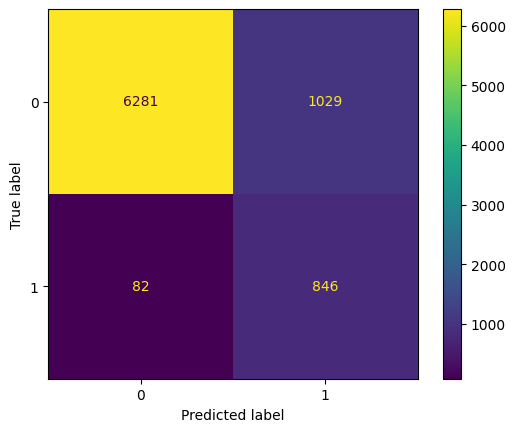

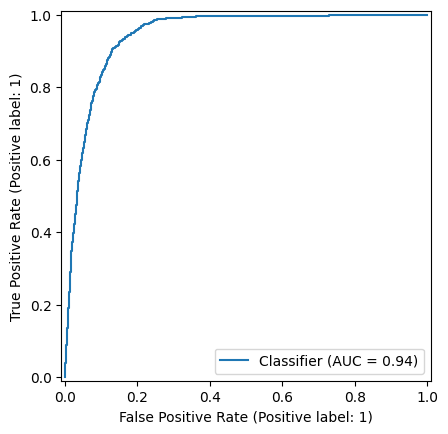

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

10) Random Forest (comparison)

RF Accuracy: 0.9169701383831027
RF Precision: 0.7170818505338078
RF Recall: 0.43426724137931033
RF F1: 0.5409395973154363
RF ROC AUC: 0.9490777129817445


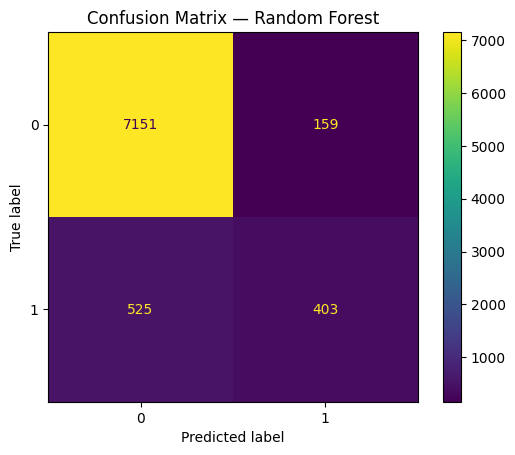

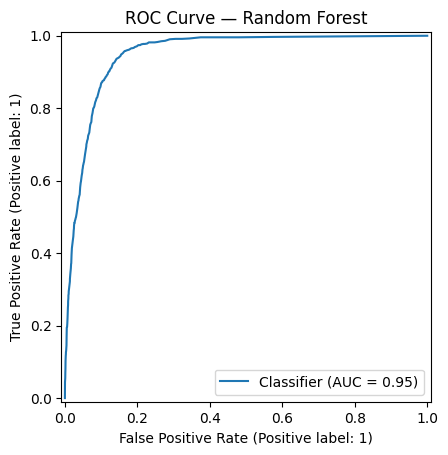

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",  # helps with imbalance
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Precision:", precision_score(y_test, y_pred_rf))
print("RF Recall:", recall_score(y_test, y_pred_rf))
print("RF F1:", f1_score(y_test, y_pred_rf))
print("RF ROC AUC:", roc_auc_score(y_test, y_proba_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix — Random Forest")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC Curve — Random Forest")
plt.show()


11) XGBoost (comparison)

In [14]:
pip install xgboost

XGB Accuracy: 0.8693857732459335
XGB Precision: 0.46109358569926395
XGB Recall: 0.9450431034482759
XGB F1: 0.6197879858657244
XGB ROC AUC: 0.9550870618897118


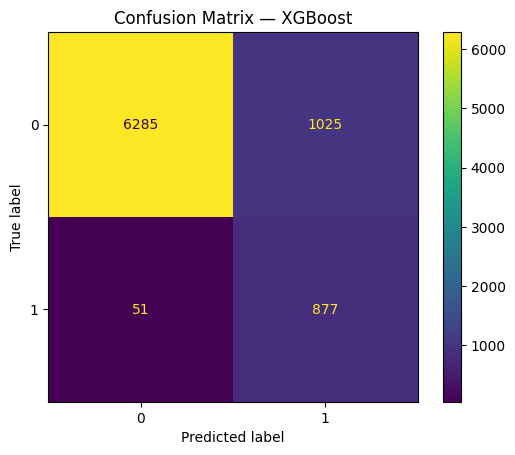

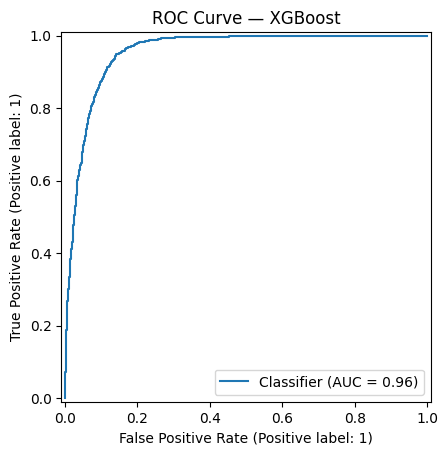

In [15]:
try:
    from xgboost import XGBClassifier

    # Compute class weight for imbalance: negatives/positives
    pos_weight = (y_train.eq(0).sum() / max(1, y_train.eq(1).sum()))

    xgb_pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="auc",
            scale_pos_weight=float(pos_weight),  # key for imbalance
            random_state=42,
            n_jobs=-1
        ))
    ])

    xgb_pipe.fit(X_train, y_train)
    y_pred_xgb = xgb_pipe.predict(X_test)
    y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

    print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print("XGB Precision:", precision_score(y_test, y_pred_xgb))
    print("XGB Recall:", recall_score(y_test, y_pred_xgb))
    print("XGB F1:", f1_score(y_test, y_pred_xgb))
    print("XGB ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
    plt.title("Confusion Matrix — XGBoost")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_proba_xgb)
    plt.title("ROC Curve — XGBoost")
    plt.show()
except Exception as e:
    print("XGBoost not available. Install with `pip install xgboost`.\nDetails:", e)
